<a href="https://colab.research.google.com/github/steelpipe75/practice-ml-competition-for-mdxq-2026/blob/main/competition_files/playground/Colab/sample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 内輪向け機械学習コンペ サンプル ノートブック

## コンペデータ取得

GitHubからリポジトリをcloneしてデータを持ってくる

In [1]:
REPO_URL = "https://github.com/steelpipe75/practice-ml-competition-for-mdxq-2026"
REPO_NAME = "practice-ml-competition-for-mdxq-2026"

In [2]:
!git clone {REPO_URL}

fatal: destination path 'practice-ml-competition-for-mdxq-2026' already exists and is not an empty directory.


## ライブラリをインポート

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression as LR
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error as MSE

## コンペ配布データ読み込み

### 学習用データ読み込み

In [4]:
train_df = pd.read_csv(f"./{REPO_NAME}/competition_files/data/train.csv")

In [5]:
train_df

,id,temperature,sunshine_h,humidity,ice_sales
0,1,23.2,6.2,56.5,324
1,2,31.3,5.2,69.0,640
2,3,28.2,3.9,80.6,306
3,4,26.4,6.9,75.6,477
4,5,20.2,6.1,78.2,267
...,...,...,...,...,...
495,496,22.9,2.5,73.4,77
496,497,26.2,7.5,71.7,573
497,498,19.1,2.8,66.2,31
498,499,31.6,7.7,63.3,789


### 評価用データ読み込み

In [6]:
test_df = pd.read_csv(f"./{REPO_NAME}/competition_files/data/test.csv")

In [7]:
test_df

,id,temperature,sunshine_h,humidity
0,501,24.7,3.0,66.0
1,502,28.2,3.0,62.6
2,503,24.6,3.9,61.5
3,504,23.6,3.1,59.9
4,505,24.9,3.4,56.4
...,...,...,...,...
295,796,38.6,10.8,33.2
296,797,39.1,9.9,31.7
297,798,35.9,9.8,30.4
298,799,36.9,10.8,33.3


### サンプル投稿ファイル読み込み

In [8]:
submit = pd.read_csv(f"./{REPO_NAME}/competition_files/data/sample_submission.csv")

In [9]:
submit

,id,ice_sales
0,501,0
1,502,0
2,503,0
3,504,0
4,505,0
...,...,...
295,796,0
296,797,0
297,798,0
298,799,0


## 前処理

### 説明変数、目的変数に分割

In [10]:
X = train_df[["temperature", "sunshine_h", "humidity"]]
y = train_df["ice_sales"]

In [11]:
X

,temperature,sunshine_h,humidity
0,23.2,6.2,56.5
1,31.3,5.2,69.0
2,28.2,3.9,80.6
3,26.4,6.9,75.6
4,20.2,6.1,78.2
...,...,...,...
495,22.9,2.5,73.4
496,26.2,7.5,71.7
497,19.1,2.8,66.2
498,31.6,7.7,63.3


In [12]:
y

,ice_sales
0,324
1,640
2,306
3,477
4,267
...,...
495,77
496,573
497,31
498,789


In [13]:
X_test = test_df[["temperature", "sunshine_h", "humidity"]]

In [14]:
X_test

,temperature,sunshine_h,humidity
0,24.7,3.0,66.0
1,28.2,3.0,62.6
2,24.6,3.9,61.5
3,23.6,3.1,59.9
4,24.9,3.4,56.4
...,...,...,...
295,38.6,10.8,33.2
296,39.1,9.9,31.7
297,35.9,9.8,30.4
298,36.9,10.8,33.3


### 訓練用データ、検証用データに分割

In [15]:
X_train, X_eval, y_train, y_eval = train_test_split(X, y)

In [16]:
X_train

,temperature,sunshine_h,humidity
251,23.4,7.6,66.9
491,26.7,6.2,63.1
273,30.8,4.4,51.4
456,18.2,5.1,74.1
355,27.0,3.1,80.6
...,...,...,...
160,23.1,4.1,78.9
321,28.0,2.0,55.6
15,20.6,2.2,82.4
442,23.2,5.9,73.5


In [17]:
y_train

,ice_sales
251,504
491,501
273,514
456,121
355,243
...,...
160,189
321,244
15,0
442,317


In [18]:
X_eval

,temperature,sunshine_h,humidity
85,22.6,3.4,66.4
423,24.9,6.8,55.2
24,24.4,7.0,83.0
96,25.3,6.0,57.7
228,30.5,3.2,84.4
...,...,...,...
394,22.8,6.0,61.8
44,21.6,5.7,81.0
75,28.2,7.7,65.0
264,30.3,2.2,50.4


In [19]:
y_eval

,ice_sales
85,112
423,497
24,421
96,483
228,372
...,...
394,341
44,252
75,715
264,330


## モデルを訓練

In [20]:
model = LR()

In [21]:
model.fit(X_train, y_train)

LinearRegression()

## 訓練済みモデルによる予測（検証用データ）

In [22]:
y_pred_eval = model.predict(X_eval)

In [23]:
y_pred_eval

array([ 147.75214748,  503.06337774,  450.55478396,  452.46872189,
        375.31999963,  396.52996257,  552.08727946,  404.23585091,
        390.42930549,  337.52642391,  373.60315203,  344.05300556,
        562.05809223,  259.28469047,  190.22100226,  334.65354557,
        310.19759548,  276.70017916,  565.04537418,  333.30177808,
        239.49268706,  266.48539103,  153.41132763,  199.16527692,
        491.96152194,  510.43446916,  -31.46029523,  681.06203763,
        247.65301735,  517.12962377,  251.27538997,  609.24404158,
        486.03478539,  324.16250907,  -64.99927406,  408.13278618,
        584.51598398,  246.24807592,  160.0058401 ,  154.53746038,
         13.13230179,  408.9441734 ,  145.26931092,   58.74859757,
        531.88832833,  509.05801907,  458.88123206,  589.34154943,
        451.08140275,  301.3018375 ,   81.34905212,  355.15202102,
        378.98534042,  269.51917181, -115.69388173,  475.19767267,
        495.91336994,  306.88850867,  573.69431746,  501.67286

予測精度の可視化

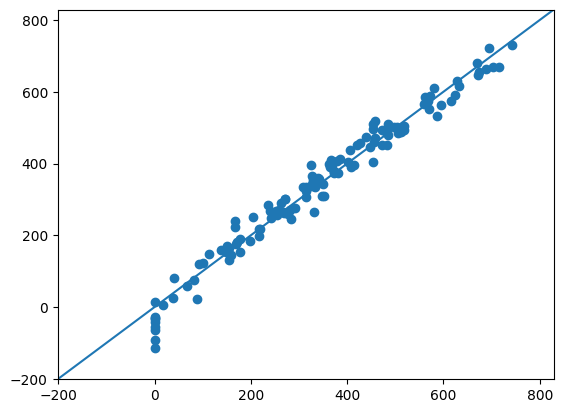

In [24]:
plt.scatter(y_eval, y_pred_eval)

y_eval_min = np.min(y_eval)
y_eval_max = np.max(y_eval)
y_pred_eval_min = np.min(y_pred_eval)
y_pred_eval_max = np.max(y_pred_eval)
y_min = np.minimum(y_eval_min, y_pred_eval_min)
y_max = np.maximum(y_eval_max, y_pred_eval_max)

y_range = y_max - y_min

lim_min = y_min - (y_range * 0.1)
lim_max = y_max + (y_range * 0.1)

plt.xlim([lim_min, lim_max])
plt.ylim([lim_min, lim_max])

plt.plot([lim_min, lim_max], [lim_min, lim_max])

plt.show()

In [25]:
mse_eval = MSE(y_eval, y_pred_eval)
rmse_eval = np.sqrt(mse_eval)

In [26]:
f"{rmse_eval=}"

'rmse_eval=np.float64(31.535714499427407)'

## 訓練済みモデルによる予測（評価用データ）

In [27]:
y_pred_test = model.predict(X_test)

In [28]:
y_pred_test

array([ 191.57133705,  319.54104119,  263.71599517,  171.77442336,
        245.84325122,  426.24344057,  393.93975569,  235.88305447,
        427.42837389,  411.05983387,  334.02134734,  245.04874389,
         99.01690204,  328.86801825,  219.95453165,  395.87060054,
        379.39366875,  486.52201875,  291.53983264,  524.65491646,
        483.52803565,  417.43466938,  331.77151093,  211.26159677,
        390.58281646,  258.17546465,  547.77073655,  246.26150527,
        246.08830109,  404.56108028,  351.43292115,  586.15395259,
        386.86261503,  234.89066036,  469.93837992,  204.45832946,
        218.27888837,   96.41789704,  195.72951178,  348.09393634,
        290.65974517,  443.38045172,  463.86662543,  389.42711785,
        333.8090358 ,  388.12637427,  350.54615857,  377.88273663,
        269.28118225,  330.26871366,  348.06825833,  384.81135572,
        384.50755835,  413.25613816,  375.12922525,  161.68253186,
        539.17107937,  329.21161329,  355.75966884,  281.18851

## 採点用投稿ファイル作成

In [29]:
submit["ice_sales"] = y_pred_test

In [30]:
submit

,id,ice_sales
0,501,191.571337
1,502,319.541041
2,503,263.715995
3,504,171.774423
4,505,245.843251
...,...,...
295,796,1319.705958
296,797,1272.300305
297,798,1155.743646
298,799,1260.345500


In [31]:
submit.to_csv("submit.csv", index=False)